In [1]:
# load_digits 함수로 데이터 준비
# example-04 파일의 작업을 적용해서 모델 훈련 및 테스트 (LogisticRegression 모델 사용)

In [2]:
# 패키지 (모듈) 준비
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.datasets import load_digits

import pickle

In [3]:
# 데이터 준비 1
bc_dataset = load_digits()
X = bc_dataset['data']
y = bc_dataset['target']

[0 1 2 3 4 5 6 7 8 9] (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([178, 182, 177, 183, 181, 182, 181, 179, 174, 180]))
(64,)
2


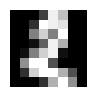

In [4]:
# 데이터 확인
# print( bc_dataset['DESCR'] )
print( bc_dataset['target_names'], np.unique(y, return_counts=True) )

print(X[0].shape)

print(y[2])
plt.figure(figsize=(1, 1))
plt.imshow(X[2].reshape((8,8)), cmap='gray') # 이미지를 화면에 출력
plt.axis('off')
plt.show()

In [5]:
# 데이터 준비 2 : 훈련 세트와 테스트 세트 분할
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
# 모델 준비 (생성)

# log_reg = LogisticRegression()
log_reg = LogisticRegression(max_iter=1000) # 성능 개선이 유지되는 동안 최대 반복 횟수 지정

In [7]:
# 모델 훈련 (학습)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
# 모델 평가

log_reg.score(X_train, y_train), log_reg.score(X_test, y_test)

(1.0, 0.9583333333333334)

In [9]:
# 모델 성능 개선을 위해 규제 적용

scores = []
for c in [0.01, 0.1, 1, 10, 100, 1000, 10000]: # 규제 강도를 변경하면서 모델 성능 테스트
    log_reg3 = LogisticRegression(penalty='l2', C=c, max_iter=1000)
    log_reg3.fit(X_train, y_train)
    train_score, test_score = \
        log_reg3.score(X_train, y_train), log_reg3.score(X_test, y_test)
    scores.append( (c, train_score, test_score) )

scores

[(0.01, 0.9951287404314544, 0.9638888888888889),
 (0.1, 1.0, 0.9611111111111111),
 (1, 1.0, 0.9583333333333334),
 (10, 1.0, 0.9611111111111111),
 (100, 1.0, 0.9694444444444444),
 (1000, 1.0, 0.9666666666666667),
 (10000, 1.0, 0.9638888888888889)]

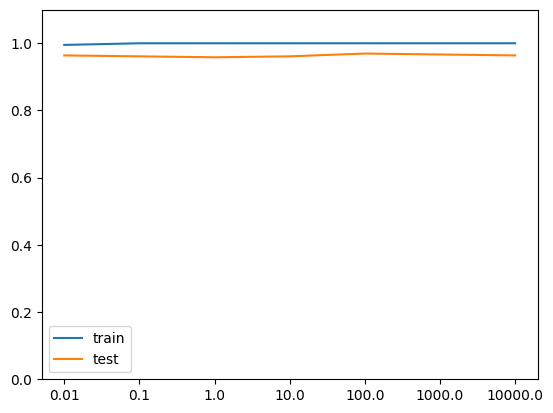

In [10]:
# 훈련 결과 시각화

scores_array = np.array(scores)
scores_array

scores_df = pd.DataFrame(scores, columns=['C', 'train_score', 'test_score'])
scores_df

plt.plot(scores_df['C'].astype('str'), scores_df['train_score'], label='train')
plt.plot(scores_df['C'].astype('str'), scores_df['test_score'], label='test')
plt.ylim(0, 1.1)
plt.legend()
plt.show()

In [11]:
# 최적의 하이퍼 파라미터를 적용해서 최종 모델 훈련

final_log_reg = LogisticRegression(penalty='l2', C=1000)

final_log_reg.fit(X, y)

with open('models/digit_reg_model.pickle', 'wb') as f:
    pickle.dump(final_log_reg, f)